# Smart Posture Corrector

Tugas Besar IF4051 IOT

- Tazkia Nizami - 13522032
- Bagas Sambega Rosyada - 13522071
- Raden Francisco Trianto Bratadiningrat - 13522091


.

### Main Problem: Predict Bad Posture From MPU6050 Data

## Table Of Contents
1. Setup
2. Load Data
3. Data Analysis & EDA
4. Preprocessing
5. Baseline Model
6. Hypotheses & Feature Engineering
7. Save Model

## 1 - Setup



### 1.1 Install Extra Dependencies

In [79]:
%pip install pandas numpy scipy scikit-learn matplotlib seaborn requests xgboost lightgbm catboost scikeras tensorflow==2.12.0 jinja2 keras micromlgen

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for micromlgen: filename=micromlgen-1.1.28-py3-none-any.whl size=32202 sha256=0e6bca876b67592dffa520847f1f63ce7ea446110d166d5bd1b52efe7942670e
  Stored in directory: /home/nohaitch/.cache/pip/wheels/aa/3a/19/9fd4635f110202e18f3b4bb631e90287ba06eb406999726cb9
Successfully built micromlgen
Note: you may need to restart the kernel to use updated packages.


### 1.2 Import Modules

In [81]:
# ============================================================================
# STANDARD LIBRARY
# ============================================================================
import os
import sys
import pickle
import tempfile
import warnings
import re
import zipfile

# ============================================================================
# DATA & COMPUTATION
# ============================================================================
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

# ============================================================================
# VISUALIZATION
# ============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# Matplotlib inline (Jupyter only)
%matplotlib inline

# Seaborn theme
sns.set_theme(style="whitegrid", palette="tab20")

# ============================================================================
# SCIKIT-LEARN: PREPROCESSING & MODEL SELECTION
# ============================================================================
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.model_selection import GridSearchCV, KFold, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.base import clone

# ============================================================================
# SCIKIT-LEARN: METRICS
# ============================================================================
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, f1_score

# ============================================================================
# SCIKIT-LEARN: CLASSICAL ML MODELS
# ============================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier, GradientBoostingClassifier

# ============================================================================
# GRADIENT BOOSTING LIBRARIES
# ============================================================================
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# ============================================================================
# DEEP LEARNING: TENSORFLOW & KERAS
# ============================================================================
import tensorflow as tf
import keras
from keras import layers
from keras.utils import to_categorical

# ============================================================================
# UTILITIES
# ============================================================================
import joblib
import requests


# ============================================================================
# MODEL EXTRACTION
# ============================================================================
from micromlgen import port


# Suppress warnings
warnings.filterwarnings("ignore")

## 2 - Load Data


### 2.1. Read Data

In [31]:
df = pd.read_csv("../data/dataset1.csv")
df

,timestamp,rawAccX,rawAccY,rawAccZ,rawGyroX,rawGyroY,rawGyroZ,rawKemiringanX,rawKemiringanY,offsetKemiringanX,offsetKemiringanY,kemiringanX,kemiringanY,gyroOffsetX,gyroOffsetY,gyroOffsetZ,kecepatanRotasiX,kecepatanRotasiY,kecepatanRotasiZ,label
0,511894,-14120,-384,7652,453,-321,-29.0,-2.87,61.52,-2.06,66.84,-0.81,-5.33,561.04,-122.29,18.72,-0.82,-1.52,-0.36,duduk_tegak
1,512097,-14088,-488,7476,643,-210,24.0,-3.73,62.00,-2.06,66.84,-1.67,-4.85,561.04,-122.29,18.72,0.63,-0.67,0.04,duduk_tegak
2,512300,-14284,-432,7344,482,-156,-61.0,-3.37,62.75,-2.06,66.84,-1.30,-4.09,561.04,-122.29,18.72,-0.60,-0.26,-0.61,duduk_tegak
3,512503,-14216,-404,7604,555,-61,3.0,-3.04,61.82,-2.06,66.84,-0.98,-5.02,561.04,-122.29,18.72,-0.05,0.47,-0.12,duduk_tegak
4,512706,-14208,-520,7364,471,-222,54.0,-4.04,62.54,-2.06,66.84,-1.98,-4.30,561.04,-122.29,18.72,-0.69,-0.76,0.27,duduk_tegak
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2944,141664,-9388,64,13844,370,-291,253.0,0.26,34.14,1.30,41.02,-1.04,-6.88,356.42,-270.82,308.67,0.10,-0.15,-0.42,berdiri_bungkuk
2945,141867,-9416,124,13764,579,-391,190.0,0.52,34.38,1.30,41.02,-0.79,-6.65,356.42,-270.82,308.67,1.70,-0.92,-0.91,berdiri_bungkuk
2946,142070,-9376,52,14088,455,-149,309.0,0.21,33.64,1.30,41.02,-1.09,-7.38,356.42,-270.82,308.67,0.75,0.93,0.00,berdiri_bungkuk
2947,142274,-9292,188,13924,577,-465,138.0,0.77,33.71,1.30,41.02,-0.53,-7.31,356.42,-270.82,308.67,1.68,-1.48,-1.30,berdiri_bungkuk


In [32]:
df.columns

Index(['timestamp', 'rawAccX', 'rawAccY', 'rawAccZ', 'rawGyroX', 'rawGyroY',
       'rawGyroZ', 'rawKemiringanX', 'rawKemiringanY', 'offsetKemiringanX',
       'offsetKemiringanY', 'kemiringanX', 'kemiringanY', 'gyroOffsetX',
       'gyroOffsetY', 'gyroOffsetZ', 'kecepatanRotasiX', 'kecepatanRotasiY',
       'kecepatanRotasiZ', 'label'],
      dtype='object')

### 2.2. Data Overview

#### 2.2.1. Read Data

In [33]:
train = df.copy()
train.head()

,timestamp,rawAccX,rawAccY,rawAccZ,rawGyroX,rawGyroY,rawGyroZ,rawKemiringanX,rawKemiringanY,offsetKemiringanX,offsetKemiringanY,kemiringanX,kemiringanY,gyroOffsetX,gyroOffsetY,gyroOffsetZ,kecepatanRotasiX,kecepatanRotasiY,kecepatanRotasiZ,label
0,511894,-14120,-384,7652,453,-321,-29.0,-2.87,61.52,-2.06,66.84,-0.81,-5.33,561.04,-122.29,18.72,-0.82,-1.52,-0.36,duduk_tegak
1,512097,-14088,-488,7476,643,-210,24.0,-3.73,62.00,-2.06,66.84,-1.67,-4.85,561.04,-122.29,18.72,0.63,-0.67,0.04,duduk_tegak
2,512300,-14284,-432,7344,482,-156,-61.0,-3.37,62.75,-2.06,66.84,-1.30,-4.09,561.04,-122.29,18.72,-0.60,-0.26,-0.61,duduk_tegak
3,512503,-14216,-404,7604,555,-61,3.0,-3.04,61.82,-2.06,66.84,-0.98,-5.02,561.04,-122.29,18.72,-0.05,0.47,-0.12,duduk_tegak
4,512706,-14208,-520,7364,471,-222,54.0,-4.04,62.54,-2.06,66.84,-1.98,-4.30,561.04,-122.29,18.72,-0.69,-0.76,0.27,duduk_tegak


In [34]:
label_column = 'label'

numerical_columns = train.select_dtypes(include=['number']).columns

categorical_columns = train.columns.drop(numerical_columns).drop(label_column)

print("Label Columns: ", label_column)
print("\nNumerical Columns:\n", numerical_columns)
print("\nCategorical Columns:\n", categorical_columns)

Label Columns:  label

Numerical Columns:
 Index(['timestamp', 'rawAccX', 'rawAccY', 'rawAccZ', 'rawGyroX', 'rawGyroY',
       'rawGyroZ', 'rawKemiringanX', 'rawKemiringanY', 'offsetKemiringanX',
       'offsetKemiringanY', 'kemiringanX', 'kemiringanY', 'gyroOffsetX',
       'gyroOffsetY', 'gyroOffsetZ', 'kecepatanRotasiX', 'kecepatanRotasiY',
       'kecepatanRotasiZ'],
      dtype='object')

Categorical Columns:
 Index([], dtype='object')


#### 2.3.1. Data Shape
Size: Row x Columns

In [35]:
print('Train:', train.shape)

Train: (2949, 20)


#### 2.3.2. Data View

In [36]:
train.head()

,timestamp,rawAccX,rawAccY,rawAccZ,rawGyroX,rawGyroY,rawGyroZ,rawKemiringanX,rawKemiringanY,offsetKemiringanX,offsetKemiringanY,kemiringanX,kemiringanY,gyroOffsetX,gyroOffsetY,gyroOffsetZ,kecepatanRotasiX,kecepatanRotasiY,kecepatanRotasiZ,label
0,511894,-14120,-384,7652,453,-321,-29.0,-2.87,61.52,-2.06,66.84,-0.81,-5.33,561.04,-122.29,18.72,-0.82,-1.52,-0.36,duduk_tegak
1,512097,-14088,-488,7476,643,-210,24.0,-3.73,62.00,-2.06,66.84,-1.67,-4.85,561.04,-122.29,18.72,0.63,-0.67,0.04,duduk_tegak
2,512300,-14284,-432,7344,482,-156,-61.0,-3.37,62.75,-2.06,66.84,-1.30,-4.09,561.04,-122.29,18.72,-0.60,-0.26,-0.61,duduk_tegak
3,512503,-14216,-404,7604,555,-61,3.0,-3.04,61.82,-2.06,66.84,-0.98,-5.02,561.04,-122.29,18.72,-0.05,0.47,-0.12,duduk_tegak
4,512706,-14208,-520,7364,471,-222,54.0,-4.04,62.54,-2.06,66.84,-1.98,-4.30,561.04,-122.29,18.72,-0.69,-0.76,0.27,duduk_tegak


#### 2.3.4. Data Info

Data types, non-null counts, and memory usage

In [37]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2949 entries, 0 to 2948
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   timestamp          2949 non-null   int64  
 1   rawAccX            2949 non-null   int64  
 2   rawAccY            2949 non-null   int64  
 3   rawAccZ            2949 non-null   int64  
 4   rawGyroX           2949 non-null   int64  
 5   rawGyroY           2949 non-null   int64  
 6   rawGyroZ           2948 non-null   float64
 7   rawKemiringanX     2948 non-null   float64
 8   rawKemiringanY     2948 non-null   float64
 9   offsetKemiringanX  2948 non-null   float64
 10  offsetKemiringanY  2948 non-null   float64
 11  kemiringanX        2948 non-null   float64
 12  kemiringanY        2948 non-null   float64
 13  gyroOffsetX        2948 non-null   float64
 14  gyroOffsetY        2948 non-null   float64
 15  gyroOffsetZ        2948 non-null   float64
 16  kecepatanRotasiX   2948 

#### 2.3.5. Numerical Data Summary
Count, Mean, STD (Standard Deviation), Min, Max

In [38]:
train.describe()

,timestamp,rawAccX,rawAccY,rawAccZ,rawGyroX,rawGyroY,rawGyroZ,rawKemiringanX,rawKemiringanY,offsetKemiringanX,offsetKemiringanY,kemiringanX,kemiringanY,gyroOffsetX,gyroOffsetY,gyroOffsetZ,kecepatanRotasiX,kecepatanRotasiY,kecepatanRotasiZ
count,2.949000e+03,2949.000000,2949.000000,2949.000000,2949.000000,2949.000000,2948.000000,2948.000000,2948.000000,2948.000000,2948.000000,2948.000000,2948.000000,2948.000000,2948.000000,2948.000000,2948.000000,2948.000000,2948.000000
mean,7.389921e+05,-12165.696846,-128.571041,9882.453713,529.189895,-202.380468,55.327001,-0.816811,51.096679,4.490614,62.483256,-5.304861,-11.387605,509.903952,-163.892188,79.649535,0.146981,-0.294403,-0.185631
std,4.684944e+05,2480.440864,903.555512,3582.107648,479.538051,463.991665,426.556423,7.341486,15.344051,12.075985,10.548295,14.954397,13.132356,78.629698,58.502786,112.268186,3.713916,3.562637,3.364734
min,2.734800e+04,-17864.000000,-4580.000000,2904.000000,-3189.000000,-5747.000000,-5849.000000,-33.540000,25.280000,-2.060000,41.020000,-63.070000,-39.140000,356.420000,-270.820000,18.720000,-27.760000,-42.400000,-47.010000
25%,5.461940e+05,-14376.000000,-608.000000,6920.000000,412.000000,-354.000000,-65.000000,-3.822500,35.610000,-2.060000,66.840000,-3.410000,-28.775000,498.010000,-192.030000,18.720000,-0.862500,-1.522500,-1.352500
50%,6.369380e+05,-13760.000000,-276.000000,8176.000000,531.000000,-205.000000,55.000000,-1.690000,59.310000,-2.060000,66.840000,-0.760000,-5.490000,561.040000,-122.290000,18.720000,0.010000,-0.470000,0.030000
75%,1.349014e+06,-9696.000000,204.000000,13516.000000,654.000000,-62.000000,173.000000,1.192500,64.042500,1.300000,66.840000,1.220000,-2.447500,561.040000,-122.290000,46.340000,1.200000,0.770000,0.950000
max,1.498611e+06,-7164.000000,3264.000000,15380.000000,4792.000000,4663.000000,3127.000000,33.500000,79.100000,29.530000,70.100000,35.560000,12.260000,561.040000,-122.290000,308.670000,33.860000,37.060000,21.510000


#### 2.3.6. Data Duplicate Check
Check if there is any duplicate data.

In [39]:
print(f"Duplicate rows in Train: {train.duplicated().sum()}")

Duplicate rows in Train: 0


## 3 - Data Analysis & EDA

### 3.1. Checking Missing Values

In [40]:
train_missing_values = pd.DataFrame({
    'Count': train.isnull().sum(),
    'Percent': (train.isnull().sum() / len(train)) * 100
})

train_missing_values.T.style.format("{:.2f}")

,timestamp,rawAccX,rawAccY,rawAccZ,rawGyroX,rawGyroY,rawGyroZ,rawKemiringanX,rawKemiringanY,offsetKemiringanX,offsetKemiringanY,kemiringanX,kemiringanY,gyroOffsetX,gyroOffsetY,gyroOffsetZ,kecepatanRotasiX,kecepatanRotasiY,kecepatanRotasiZ,label
Count,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
Percent,0.00,0.00,0.00,0.00,0.00,0.00,0.03,0.03,0.03,0.03,0.03,0.03,0.03,0.03,0.03,0.03,0.03,0.03,0.03,0.03


### 3.2. Visualization and Analysis

#### 3.2.1 Drafted (Label) Distribution

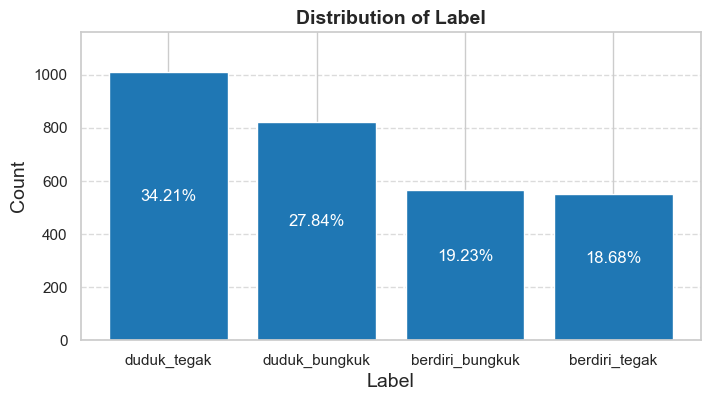

In [41]:
label_counts = train[label_column].value_counts()
total = len(train)

plt.figure(figsize=(8, 4))
bars = plt.bar(label_counts.index.astype(str), label_counts.values)

for bar in bars:
    height = bar.get_height()
    percentage = (height / total) * 100
    plt.text(bar.get_x() + bar.get_width()/2., height/2 + (height * 0.01), f'{percentage:.2f}%', ha='center', va='bottom', fontsize=12, color="white")

plt.title('Distribution of Label', fontsize=14, fontweight="bold")
plt.xlabel('Label', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.ylim(0, max(label_counts.values) * 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

#### 3.2.2 Numerical Distribution

##### 3.2.2.1 Distribution

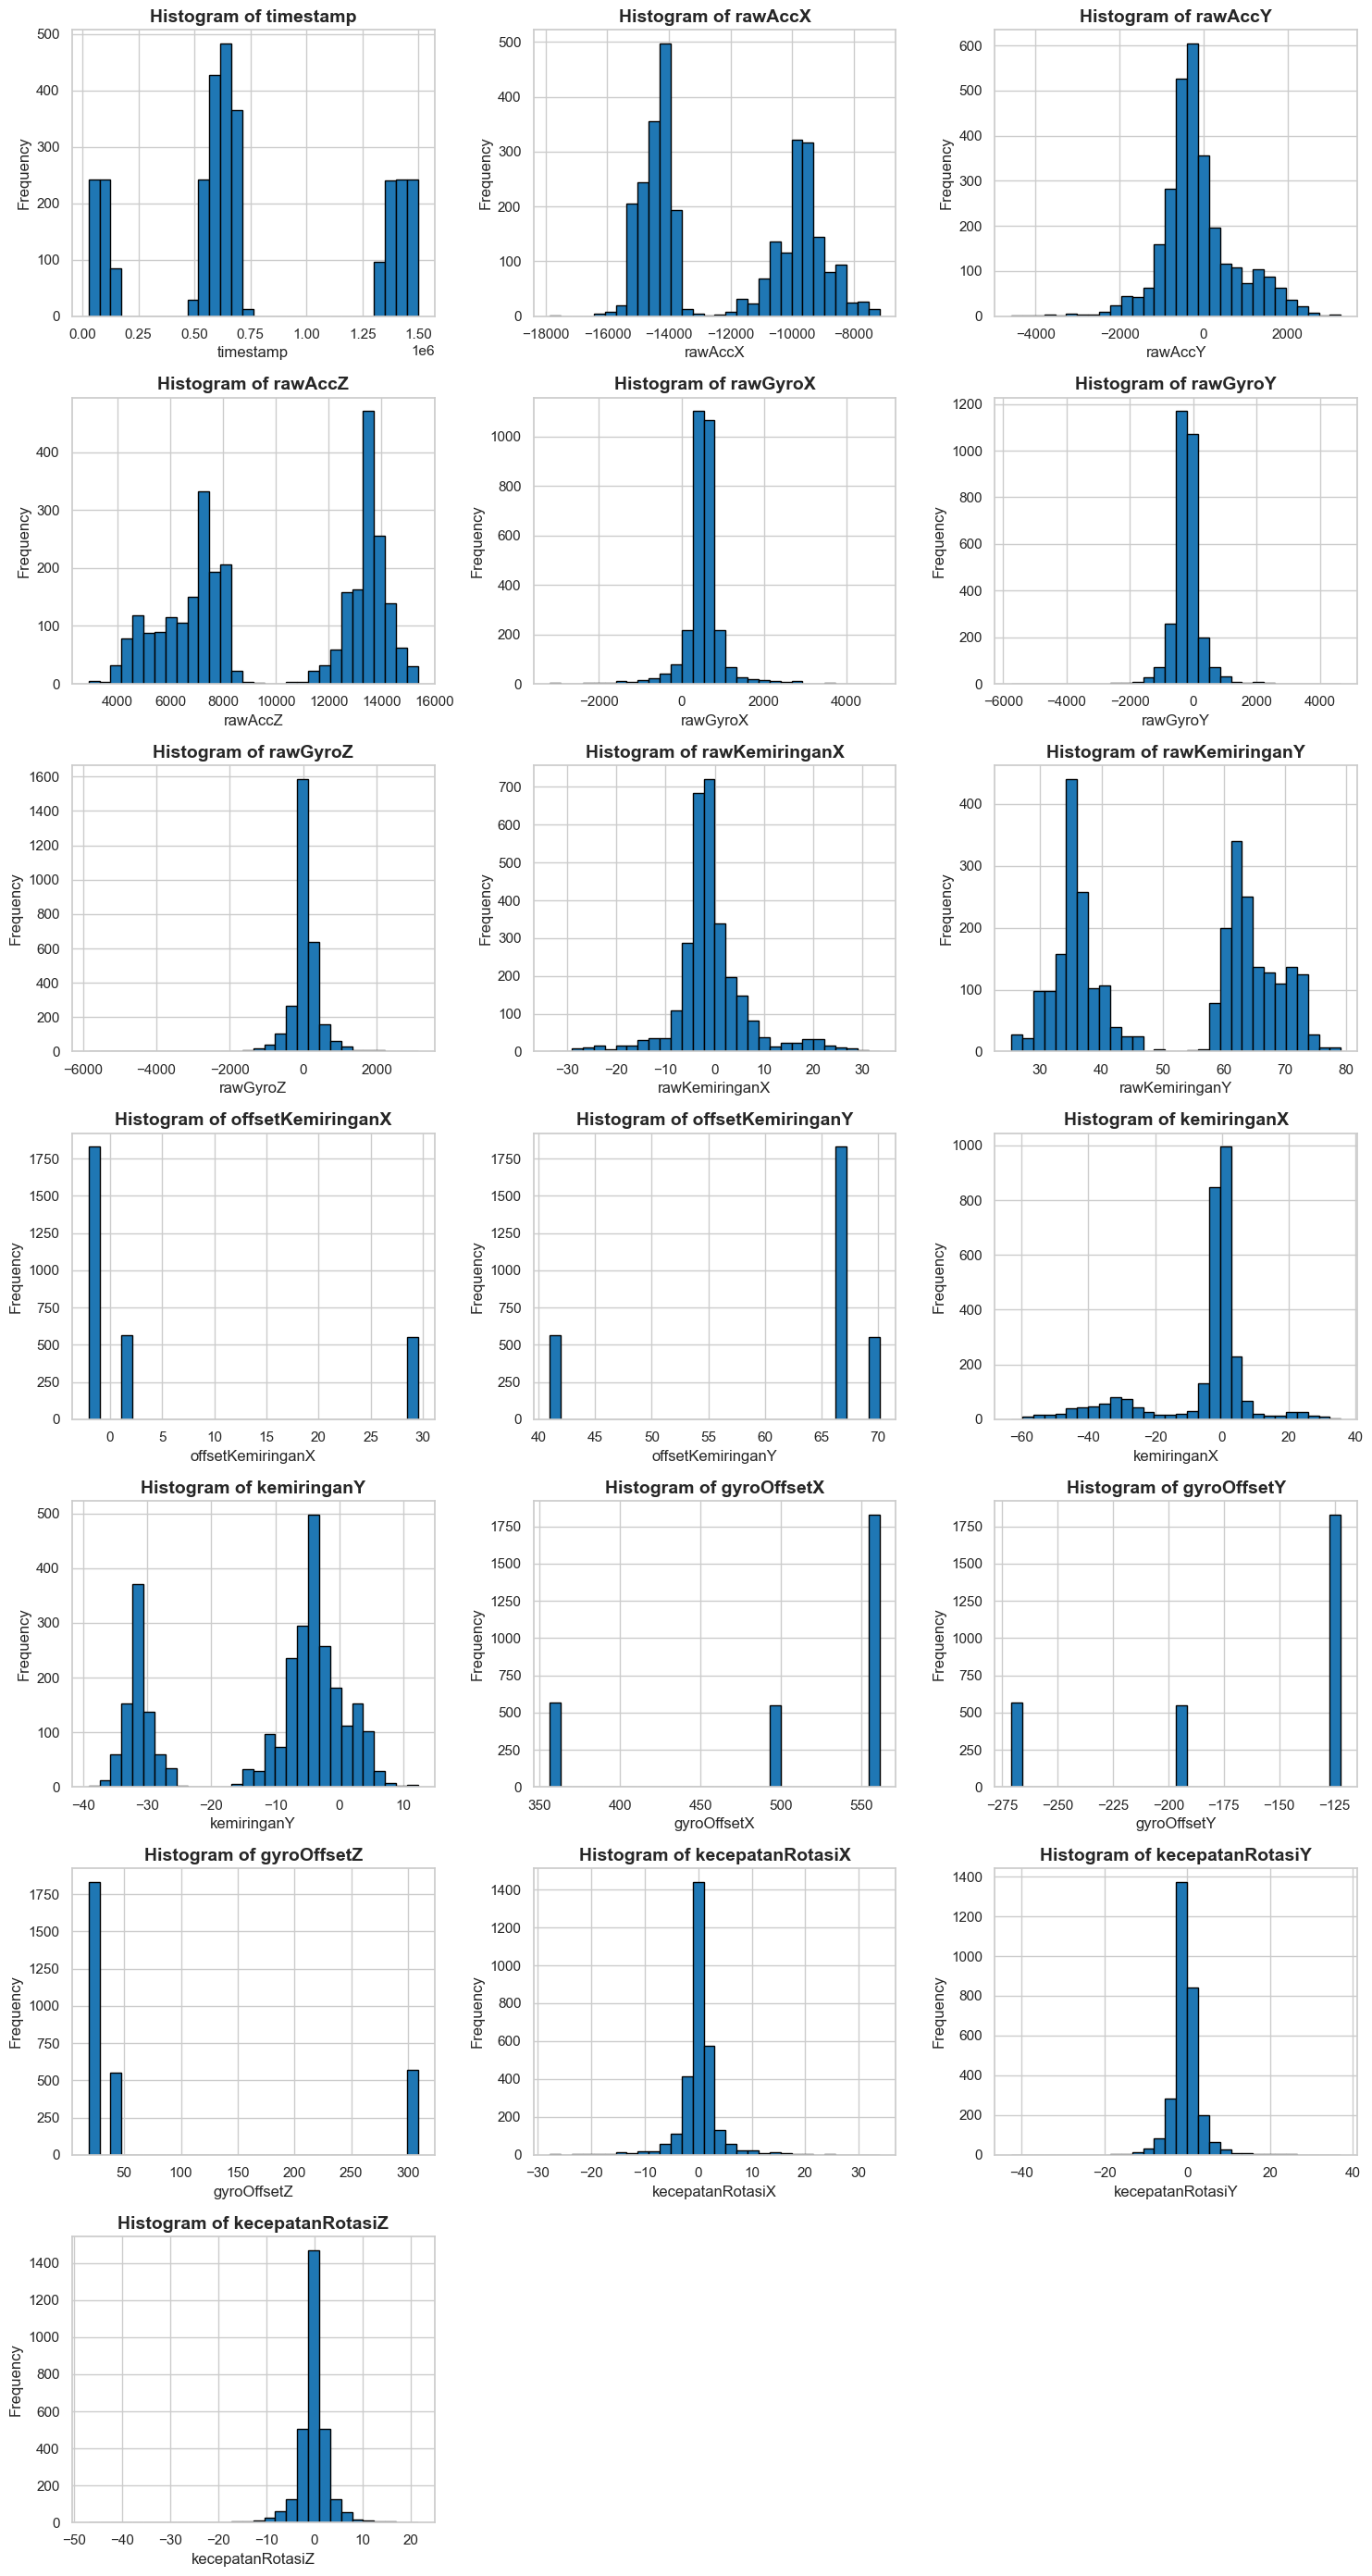

In [42]:
num_cols = len(numerical_columns)
cols = 3
rows = (num_cols + cols - 1) // cols

plt.figure(figsize=(5 * cols, 4 * rows))

for i, col in enumerate(numerical_columns, 1):
    plt.subplot(rows, cols, i)
    plt.hist(train[col].dropna(), bins=30, edgecolor='black')
    plt.title(f'Histogram of {col}', fontsize=14, fontweight='bold')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

##### 3.2.2.2 Correlation


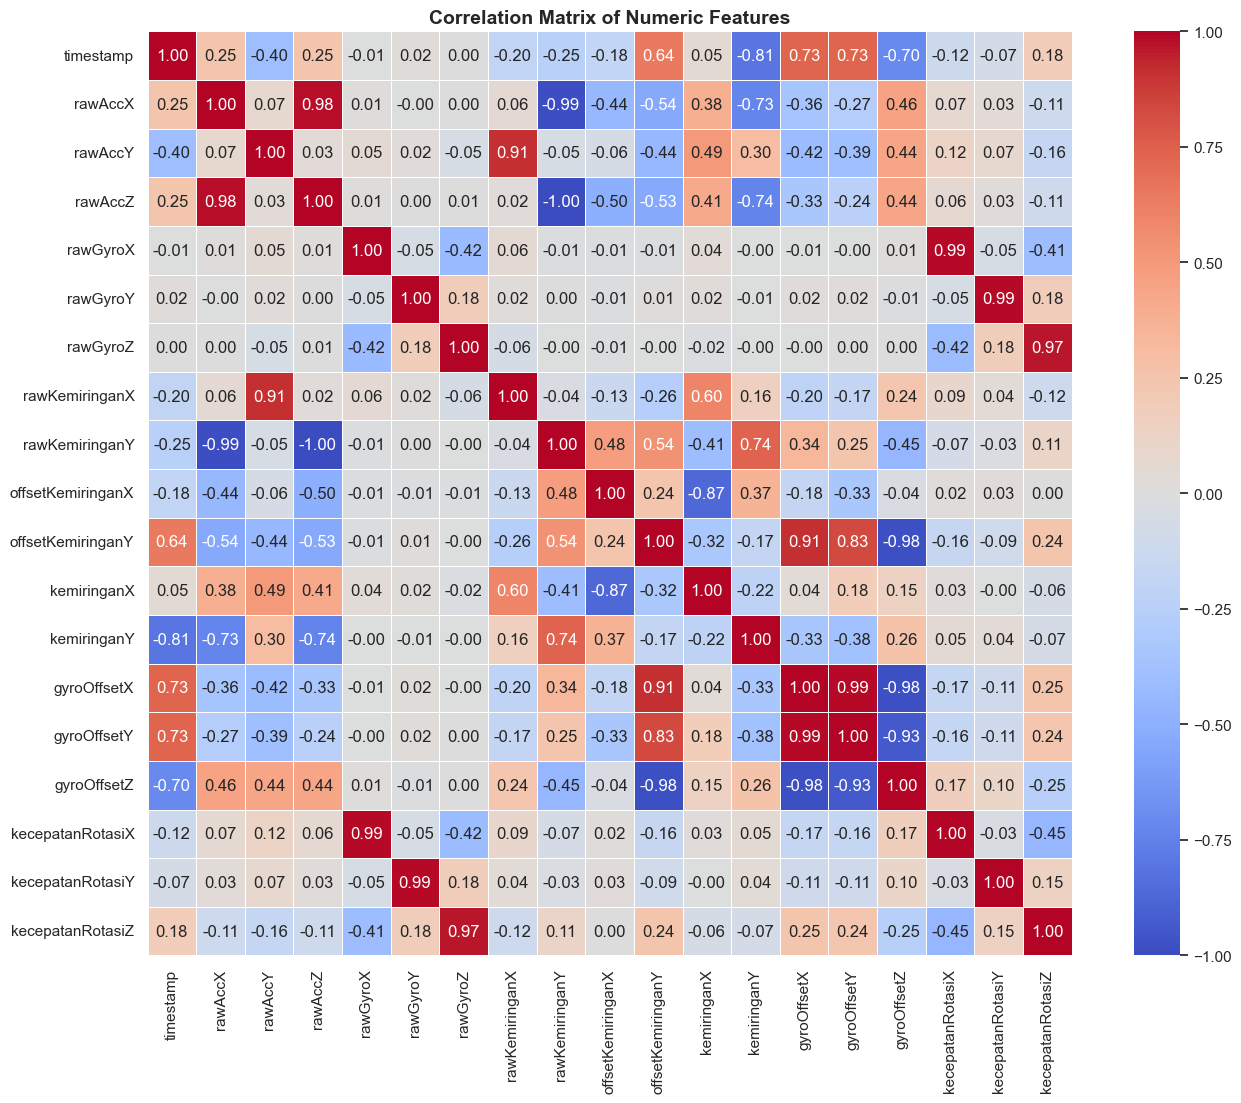

In [43]:
numeric_cols = train.select_dtypes(include=['number'])

corr_matrix = numeric_cols.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5
)

plt.title('Correlation Matrix of Numeric Features', fontsize=14, fontweight='bold')
plt.show()

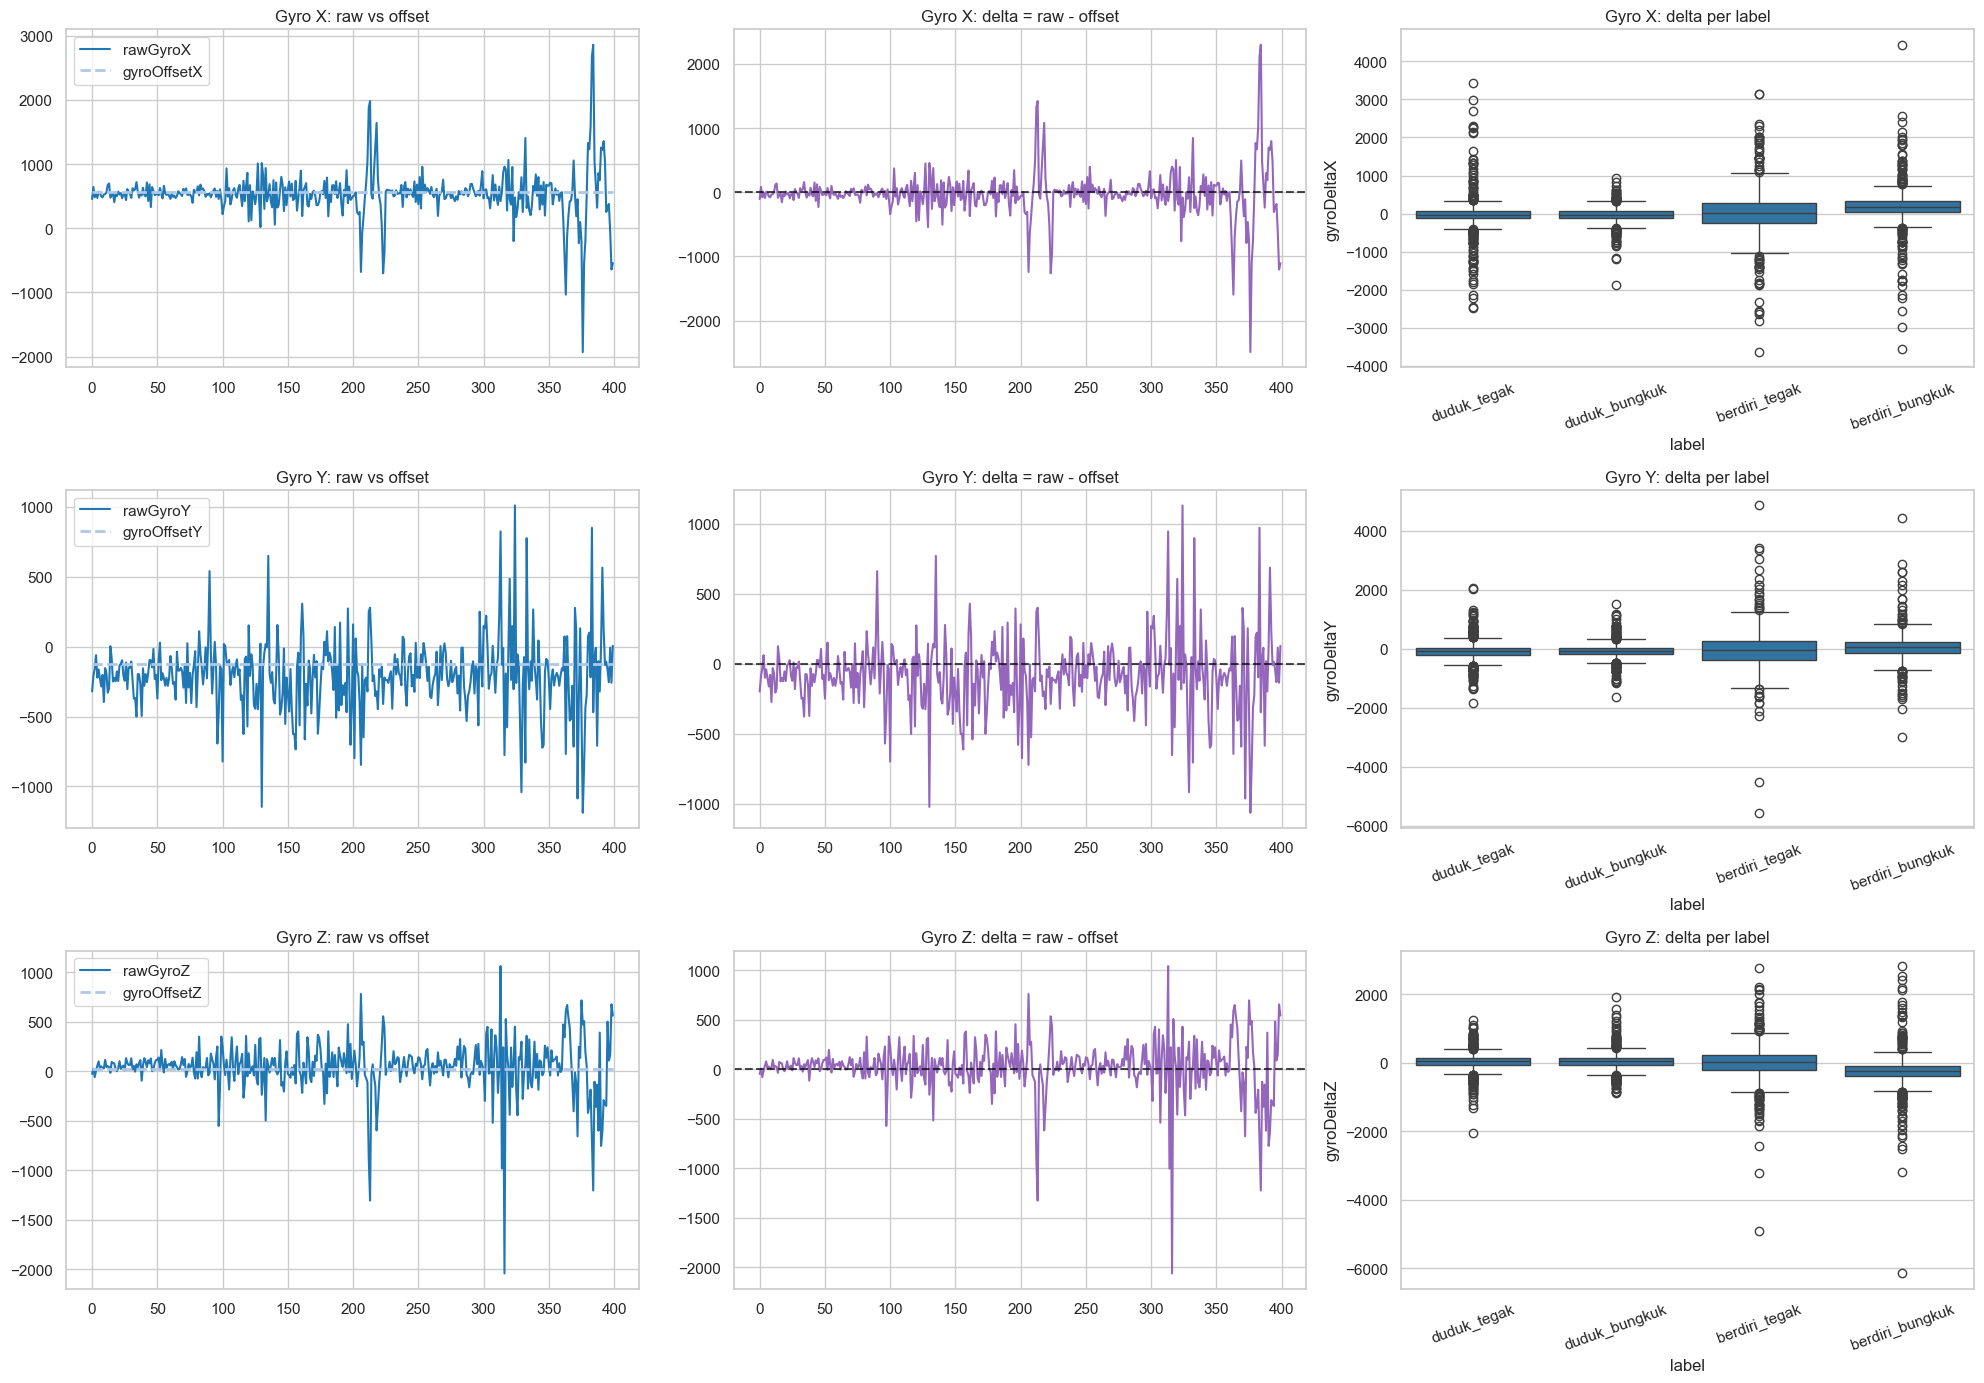

In [44]:
eda = train.copy()

gyro_raw_cols = ['rawGyroX', 'rawGyroY', 'rawGyroZ']
gyro_offset_cols = ['gyroOffsetX', 'gyroOffsetY', 'gyroOffsetZ']

for col in gyro_raw_cols + gyro_offset_cols:
    eda[col] = pd.to_numeric(eda[col], errors='coerce')

eda['gyroDeltaX'] = eda['rawGyroX'] - eda['gyroOffsetX']
eda['gyroDeltaY'] = eda['rawGyroY'] - eda['gyroOffsetY']
eda['gyroDeltaZ'] = eda['rawGyroZ'] - eda['gyroOffsetZ']

sample_n = min(400, len(eda))
plot_df = eda.iloc[:sample_n].copy()

fig, axes = plt.subplots(3, 3, figsize=(20, 14))

pairs = [
    ('rawGyroX', 'gyroOffsetX', 'gyroDeltaX', 'X'),
    ('rawGyroY', 'gyroOffsetY', 'gyroDeltaY', 'Y'),
    ('rawGyroZ', 'gyroOffsetZ', 'gyroDeltaZ', 'Z'),
]

for i, (raw_col, off_col, delta_col, axis_name) in enumerate(pairs):
    axes[i, 0].plot(plot_df.index, plot_df[raw_col], label=raw_col, linewidth=1.5)
    axes[i, 0].plot(plot_df.index, plot_df[off_col], label=off_col, linewidth=2, linestyle='--')
    axes[i, 0].set_title(f'Gyro {axis_name}: raw vs offset')
    axes[i, 0].legend()

    axes[i, 1].plot(plot_df.index, plot_df[delta_col], color='tab:purple', linewidth=1.5)
    axes[i, 1].axhline(0, color='black', linestyle='--', alpha=0.7)
    axes[i, 1].set_title(f'Gyro {axis_name}: delta = raw - offset')

    sns.boxplot(
        data=eda,
        x='label',
        y=delta_col,
        ax=axes[i, 2]
    )
    axes[i, 2].set_title(f'Gyro {axis_name}: delta per label')
    axes[i, 2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

##### 3.2.2.3 Outliers

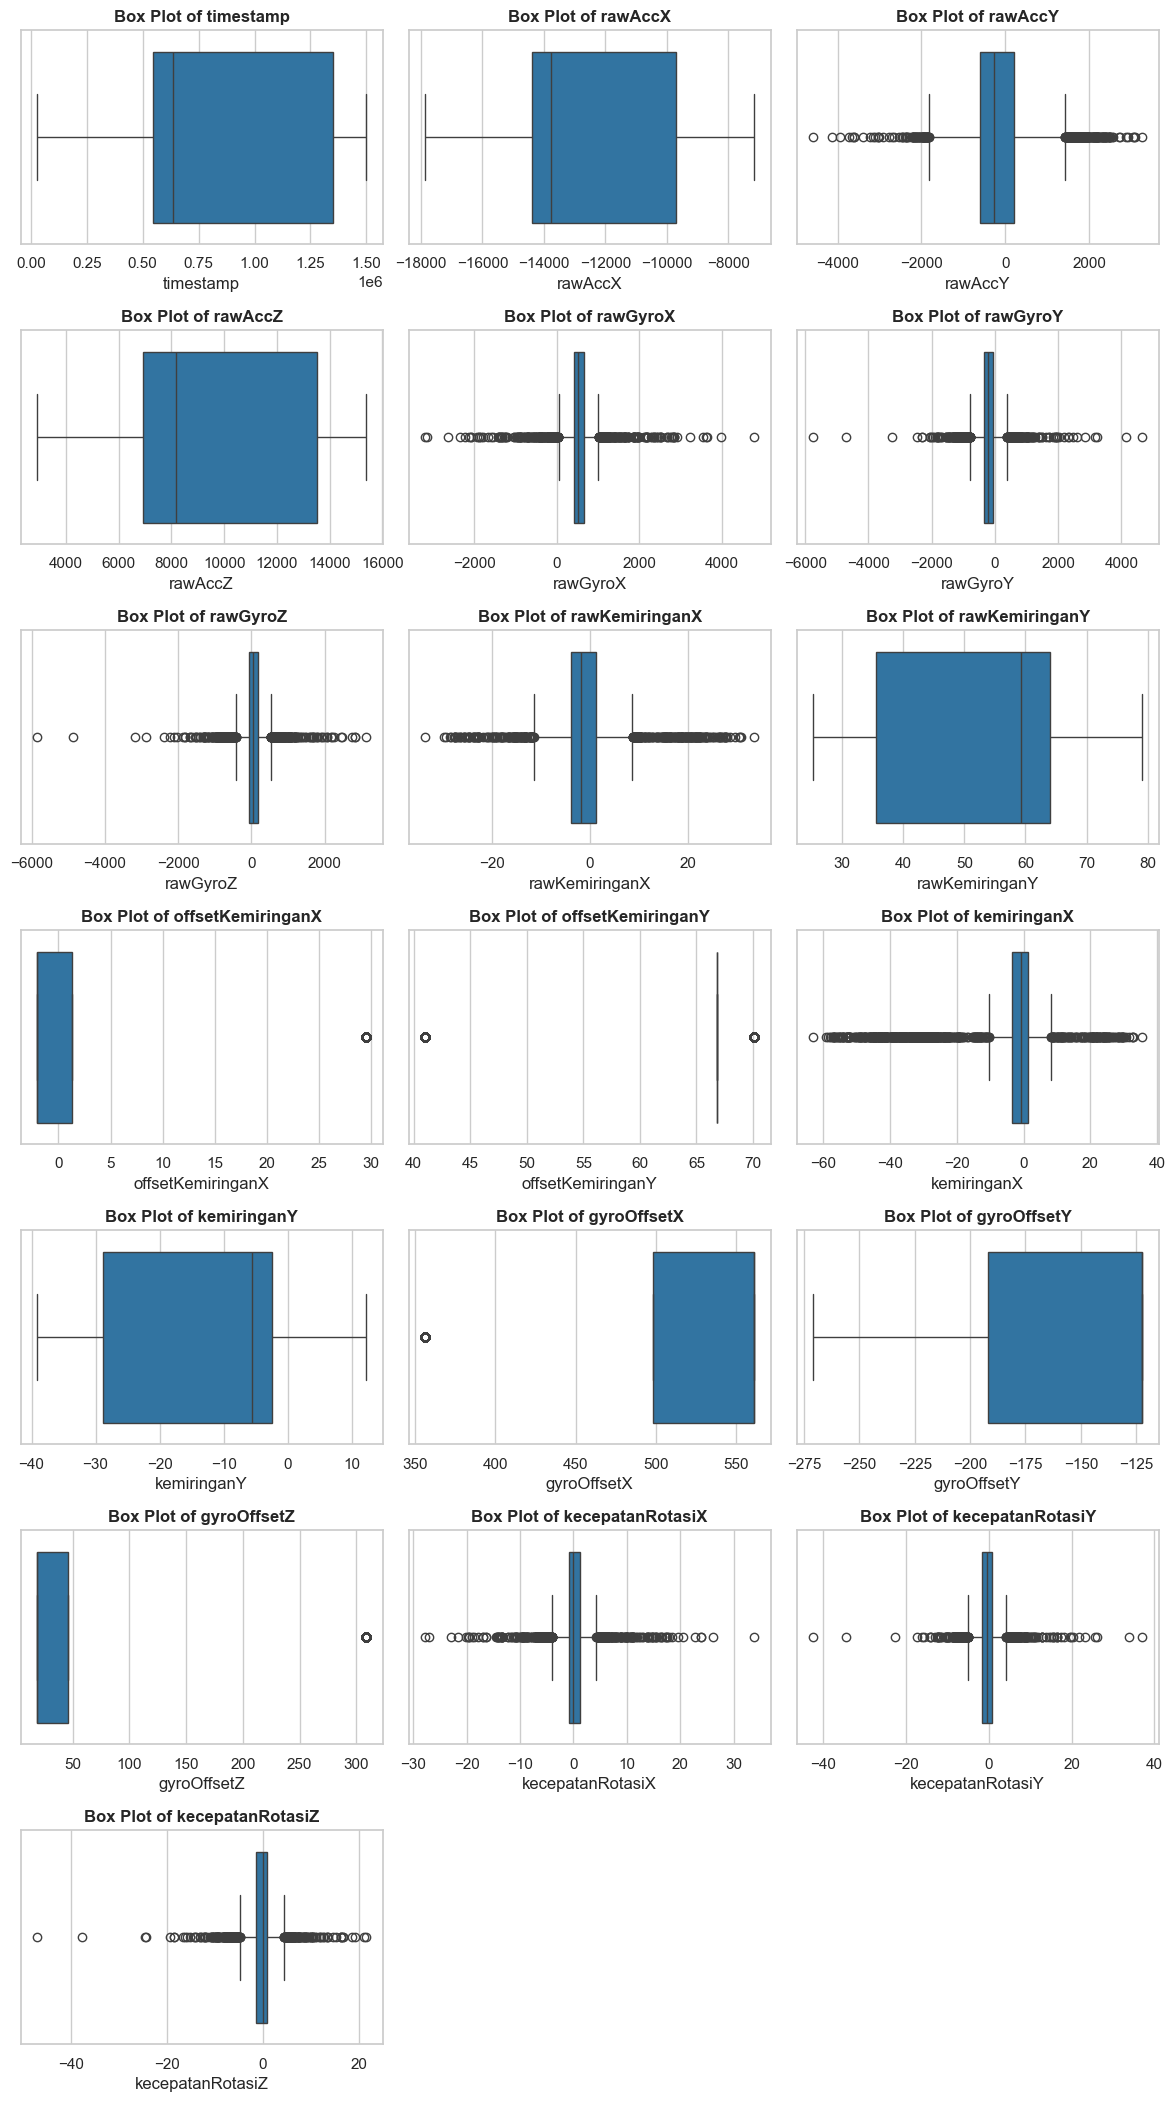

In [45]:
num_cols = len(numeric_cols)
cols = 3
rows = (num_cols + cols - 1) // cols

plt.figure(figsize=(4 * cols, 3 * rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(x=train[col])
    plt.title(f'Box Plot of {col}', fontweight='bold')
    plt.xlabel(col)

plt.tight_layout()
plt.show()

#### 3.2.3 Categorical Distribution

In [46]:
train.select_dtypes(include=['object', 'category']).columns.drop(label_column)

Index([], dtype='object')

Currently No Categorical Data.

## 4 - Preprocessing

### 4.1. Dropping Columns

#### 4.1.1. Dropping Timestamp

In [62]:
train = train.drop(columns=['timestamp'])

#### 4.1.2. Dropping Offsets

In [69]:
train = train.drop(columns=['offsetKemiringanX', 'offsetKemiringanY'])
train = train.drop(columns=['gyroOffsetX', 'gyroOffsetY', 'gyroOffsetZ'])

In [75]:
train = train.drop(columns=['kemiringanX', 'kemiringanY'])

### 4.2. Adding Feature (from Feature Engineering)

Skipped

### 4.3. Normalize Data

Skipped

### 4.4. Deal with Missing Data

Drop Missing Data

In [47]:
train = train.dropna().reset_index(drop=True)

In [74]:
pd.DataFrame({
    'Count': train.isnull().sum(),
    'Percent': (train.isnull().sum() / len(train)) * 100
}).T.style.format("{:.2f}")

,rawAccX,rawAccY,rawAccZ,rawGyroX,rawGyroY,rawGyroZ,rawKemiringanX,rawKemiringanY,kemiringanX,kemiringanY,kecepatanRotasiX,kecepatanRotasiY,kecepatanRotasiZ,label_encoded
Count,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Percent,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


### 4.5. Encoding

#### 4.5.1 Label Encoding

In [49]:
label_encoder = LabelEncoder()
train["label_encoded"] = label_encoder.fit_transform(train["label"])

label_mapping = {
    label: int(code)
    for code, label in enumerate(label_encoder.classes_)
}

print(label_mapping)

train['label_encoded'].value_counts()

{'berdiri_bungkuk': 0, 'berdiri_tegak': 1, 'duduk_bungkuk': 2, 'duduk_tegak': 3}


label_encoded
3    1009
2     821
0     567
1     551
Name: count, dtype: int64

Drop label

In [50]:
train = train.drop(columns=['label'])

label_column = 'label_encoded'

In [51]:
train.columns

Index(['timestamp', 'rawAccX', 'rawAccY', 'rawAccZ', 'rawGyroX', 'rawGyroY',
       'rawGyroZ', 'rawKemiringanX', 'rawKemiringanY', 'offsetKemiringanX',
       'offsetKemiringanY', 'kemiringanX', 'kemiringanY', 'gyroOffsetX',
       'gyroOffsetY', 'gyroOffsetZ', 'kecepatanRotasiX', 'kecepatanRotasiY',
       'kecepatanRotasiZ', 'label_encoded'],
      dtype='object')

## 5 - Baseline Model

In [52]:
X = train.drop(columns=[label_column])
y = train[label_column]

X_np = np.asarray(X)
y_np = np.asarray(y)

### 5.1. Create Base Fold to use for finding the best model
Using Stratified K-Fold since Drafted is imbalanced.

In [53]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### 5.2. The Model Comparison

In [54]:
label_encoder = LabelEncoder()
y_enc = label_encoder.fit_transform(y_np)
n_classes = len(np.unique(y_enc))

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "LogReg": Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=1000, random_state=42))]),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "ExtraTrees": ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "GradBoost": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric="mlogloss", random_state=42, n_estimators=100, max_depth=6, learning_rate=0.1),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1, n_estimators=100),
    "CatBoost": CatBoostClassifier(silent=True, random_state=42, iterations=100)
}

def get_joblib_model_size_kb(model, X, y):
    model_fitted = clone(model)
    model_fitted.fit(X, y)

    with tempfile.NamedTemporaryFile(suffix=".joblib", delete=False) as tmp:
        tmp_path = tmp.name

    joblib.dump(model_fitted, tmp_path, compress=3)
    size_kb = os.path.getsize(tmp_path) / 1024.0
    os.remove(tmp_path)
    return size_kb

scaler_dl = StandardScaler()
X_scaled = scaler_dl.fit_transform(X_np).astype(np.float32)
y_cat = to_categorical(y_enc, num_classes=n_classes)

input_dim = X_scaled.shape[1]

def build_ffnn_small(input_dim, n_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(16, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(8, activation="relu"),
        layers.Dense(n_classes, activation="softmax")
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

def build_ffnn_tiny(input_dim, n_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(8, activation="relu"),
        layers.Dense(n_classes, activation="softmax")
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

def build_cnn1d_tiny(input_dim, n_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim, 1)),
        layers.Conv1D(8, kernel_size=3, padding="same", activation="relu"),
        layers.GlobalAveragePooling1D(),
        layers.Dense(8, activation="relu"),
        layers.Dense(n_classes, activation="softmax")
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

def evaluate_keras_cv(build_fn, X_data, y_data, y_labels, cv, epochs=20, batch_size=32, is_cnn=False):
    scores = []

    for train_idx, val_idx in cv.split(X_data, y_labels):
        X_train, X_val = X_data[train_idx], X_data[val_idx]
        y_train, y_val = y_data[train_idx], y_data[val_idx]

        if is_cnn:
            X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
            X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))

        model = build_fn(input_dim, n_classes)

        es = keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )

        model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=batch_size,
            verbose=0,
            callbacks=[es]
        )

        y_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
        y_true = np.argmax(y_val, axis=1)
        f1 = f1_score(y_true, y_pred, average="weighted")
        scores.append(f1)

    return float(np.mean(scores)), float(np.std(scores))

def convert_to_tflite_int8_and_get_size(build_fn, X_data, y_data, is_cnn=False):
    model = build_fn(input_dim, n_classes)

    X_fit = X_data
    if is_cnn:
        X_fit = X_fit.reshape((X_fit.shape[0], X_fit.shape[1], 1))

    model.fit(X_fit, y_data, epochs=10, batch_size=32, verbose=0)

    def representative_dataset():
        sample_count = min(100, len(X_fit))
        for i in range(sample_count):
            x = X_fit[i:i+1].astype(np.float32)
            yield [x]

    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.float32
    converter.inference_output_type = tf.float32

    tflite_model = converter.convert()
    size_kb = len(tflite_model) / 1024.0
    return size_kb

dl_models = {
    "FFNN_Tiny": {"build_fn": build_ffnn_tiny, "is_cnn": False},
    "FFNN_Small": {"build_fn": build_ffnn_small, "is_cnn": False},
    "CNN1D_Tiny": {"build_fn": build_cnn1d_tiny, "is_cnn": True}
}

model_results = []

print(f"{'Model':<18} | {'Mean F1':<10} | {'Std Dev':<10} | {'Saved Size KB':<14} | {'Type':<10}")
print("-" * 75)

for name, model in models.items():
    cv_scores = cross_val_score(model, X_np, y_enc, cv=skf, scoring="f1_weighted", n_jobs=-1)

    mean_s = cv_scores.mean()
    std_s = cv_scores.std()
    size_kb = get_joblib_model_size_kb(model, X_np, y_enc)

    model_results.append({"Model": name, "Mean_F1": mean_s, "Std_Dev": std_s, "Saved_Size_KB": size_kb, "Type": "Classical"})

    print(f"{name:<18} | {mean_s:<10.4f} | {std_s:<10.4f} | {size_kb:<14.2f} | {'Classical':<10}")

# # Deep Learning kecil
# for name, cfg in dl_models.items():
#     mean_s, std_s = evaluate_keras_cv(build_fn=cfg["build_fn"], X_data=X_scaled, y_data=y_cat, y_labels=y_enc, cv=skf, epochs=20, batch_size=32, is_cnn=cfg["is_cnn"])

#     size_kb = convert_to_tflite_int8_and_get_size(build_fn=cfg["build_fn"], X_data=X_scaled, y_data=y_cat, is_cnn=cfg["is_cnn"])

#     model_results.append({"Model": name, "Mean_F1": mean_s, "Std_Dev": std_s, "Saved_Size_KB": size_kb, "Type": "DeepLearning"})

#     print(f"{name:<18} | {mean_s:<10.4f} | {std_s:<10.4f} | {size_kb:<14.2f} | {'DeepLearning':<10}")

print("-" * 75)

Model              | Mean F1    | Std Dev    | Saved Size KB  | Type      
---------------------------------------------------------------------------
LogReg             | 1.0000     | 0.0000     | 1.90           | Classical 
RandomForest       | 1.0000     | 0.0000     | 26.92          | Classical 
ExtraTrees         | 1.0000     | 0.0000     | 32.46          | Classical 
AdaBoost           | 0.2626     | 0.0006     | 2.85           | Classical 
GradBoost          | 1.0000     | 0.0000     | 60.89          | Classical 
XGBoost            | 1.0000     | 0.0000     | 26.28          | Classical 
LightGBM           | 1.0000     | 0.0000     | 367.46         | Classical 
CatBoost           | 0.9997     | 0.0007     | 72.12          | Classical 
---------------------------------------------------------------------------


In [55]:
results_df = pd.DataFrame(model_results)


results_df = results_df.sort_values(by='Mean_F1', ascending=False).reset_index(drop=True)

results_df.style.format({'AUC': '{:.4f}', 'Std': '{:.4f}'})

,Model,Mean_F1,Std_Dev,Saved_Size_KB,Type
0,LogReg,1.000000,0.000000,1.898438,Classical
1,RandomForest,1.000000,0.000000,26.924805,Classical
2,ExtraTrees,1.000000,0.000000,32.455078,Classical
3,GradBoost,1.000000,0.000000,60.893555,Classical
4,XGBoost,1.000000,0.000000,26.279297,Classical
5,LightGBM,1.000000,0.000000,367.455078,Classical
6,CatBoost,0.999661,0.000679,72.123047,Classical
7,AdaBoost,0.262583,0.000560,2.850586,Classical


In [ ]:
raise

### 5.3. Base Fine Tuning

#### 5.3.1. Tuning Random Forest

In [ ]:
rf_params = {
    'n_estimators': [500, 750, 1000],               # Best: 750 | Tested: 300, 400, 500, 750, 1000
    'max_depth': [8, 13, 20],                       # Best: 13  | Tested: 5, 8, 10, 12, 13, 14, 15, 16, 18, 20
    'min_samples_leaf': [4, 6, 8],                  # Best: 6  | Tested: 2, 4, 5, 6, 7, 8, 10
    'max_features': ['sqrt', 'log2'],               # Best: 'sqrt'  | Tested: 'sqrt', 'log2', 0.8, 0.5, 0.3
    'bootstrap': [True, False]                      # Best: True  | Tested: True, False
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=rf_params,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=3
)

grid_rf.fit(X, y)
print(f"Best RF Params: {grid_rf.best_params_}")
print(f"Best RF AUC: {grid_rf.best_score_:.4f}")

In [ ]:
res_df = pd.DataFrame(grid_rf.cv_results_)
res_df['param_max_depth'] = res_df['param_max_depth'].astype(str)

g = sns.FacetGrid(res_df, col="param_max_features", row="param_min_samples_leaf",
                  margin_titles=True, height=4, aspect=1.2)

def draw_heatmap(*args, **kwargs):
    data = kwargs.pop('data')
    d = data.pivot_table(index='param_max_depth', columns='param_n_estimators', values='mean_test_score')
    sns.heatmap(d, annot=True, cmap='viridis', cbar=False, fmt='.4f', **kwargs)

g.map_dataframe(draw_heatmap)
g.set_axis_labels("n_estimators", "max_depth")

plt.subplots_adjust(right=0.85, top=0.9, wspace=0.3, hspace=0.1)

cbar_ax = g.fig.add_axes([0.9, 0.15, 0.03, 0.7])
sm = plt.cm.ScalarMappable(cmap='viridis')
sm.set_array(res_df['mean_test_score'])
g.fig.colorbar(sm, cax=cbar_ax)

plt.show()

In [ ]:
res_df = pd.DataFrame(grid_rf.cv_results_)

res_df['param_max_features'] = res_df['param_max_features'].astype(str)
viz_data = res_df.pivot_table(index='param_bootstrap',
                                  columns='param_max_features',
                                  values='mean_test_score')

plt.figure(figsize=(10, 5))
sns.heatmap(viz_data, annot=True, cmap='viridis', fmt='.4f')

plt.title('Random Forest: Bootstrap vs Max Features (AUC Score)')
plt.xlabel('max_features')
plt.ylabel('bootstrap')
plt.show()

Gridsearch Params for Random Forest:
- n_estimator = 750
- max_depth = 13
- min sample leaf = 6
- max features = sqrt
- bootstrap = True

In [ ]:
best_rf = RandomForestClassifier(
    n_estimators=750,
    max_depth=13,
    min_samples_leaf=6,
    max_features='sqrt',
    bootstrap=True,
    random_state=42
)

fold_counts = [3, 5, 10, 15, 20]
print(f"{'Folds':<10} | {'Mean AUC':<10} | {'Std Dev':<10}")

for k in fold_counts:
    skf_test = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    scores = cross_val_score(best_rf, X, y, cv=skf_test, scoring='roc_auc', n_jobs=-1)
    print(f"{k:<10} | {scores.mean():<10.4f} | {scores.std():<10.4f}")

Result Params for Random Forest:
- n_estimator = 750
- max_depth = 13
- min sample leaf = 6
- max features = sqrt
- bootstrap = True
- Fold = 15

#### 5.3.2 Tuning CatBoost

In [ ]:
cat_params = {
    'iterations': [500, 750, 1000, 1500],   # Best: 2000 | Tested: 100, 500, 1000, 1500, 2000, 2500, 3000
    'depth': [3, 5, 7],                     # Best: 3 | Tested: 2, 3, 4, 5, 6, 8
    'learning_rate': [0.005, 0.01, 0.05],   # Best:  0.01 | Tested: 0.001, 0.005, 0.01, 0.05, 0.1
    'l2_leaf_reg': [2, 4, 6]                # Best:  4 | Tested:  3, 4, 5, 6
}

grid_cat = GridSearchCV(
    CatBoostClassifier(silent=True, random_state=42, bootstrap_type='Bayesian'),
    param_grid=cat_params,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=3
)

grid_cat.fit(X, y)

print(f"Best CatBoost Params: {grid_cat.best_params_}")
print(f"Best CatBoost AUC: {grid_cat.best_score_:.4f}")

In [ ]:
cat_res_df = pd.DataFrame(grid_cat.cv_results_)

g = sns.FacetGrid(cat_res_df, col="param_iterations", row="param_l2_leaf_reg",
                  margin_titles=True, height=4, aspect=1.2)

def draw_cat_heatmap(*args, **kwargs):
    data = kwargs.pop('data')
    d = data.pivot_table(index='param_depth', columns='param_learning_rate', values='mean_test_score')
    sns.heatmap(d, annot=True, cmap='magma', cbar=False, fmt='.4f', **kwargs)

g.map_dataframe(draw_cat_heatmap)
g.set_axis_labels("Learning Rate", "Depth")

plt.subplots_adjust(right=0.85, top=0.9, wspace=0.3, hspace=0.4)
cbar_ax = g.fig.add_axes([0.9, 0.15, 0.03, 0.7])
sm = plt.cm.ScalarMappable(cmap='magma')
sm.set_array(cat_res_df['mean_test_score'])
g.fig.colorbar(sm, cax=cbar_ax)

plt.suptitle("CatBoost Grid Search: Depth vs Learning Rate Analysis", fontsize=16)
plt.show()

Gridsearch Params for CatBoost:
- Iteration = 2000
- Depth = 3
- Learning Rate = 0.01
- L2 leaf reg = 4

In [ ]:
best_cat = CatBoostClassifier(
    iterations=2000,
    depth=3,
    learning_rate=0.01,
    l2_leaf_reg=4,
    silent=True,
    random_state=42,
    allow_writing_files=False
)

fold_counts = [3, 5, 10, 15, 20]
print(f"{'Folds':<10} | {'Mean AUC':<10} | {'Std Dev':<10}")

for k in fold_counts:
    skf_test = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    scores = cross_val_score(best_cat, X, y, cv=skf_test, scoring='roc_auc', n_jobs=-1)
    print(f"{k:<10} | {scores.mean():<10.4f} | {scores.std():<10.4f}")

Final Params for CatBoost:
- Iteration = 2000
- Depth = 3
- Learning Rate = 0.01
- L2 leaf reg = 4
- Fold = 10

## 6 - Hypotheses & Feature Engineering

### 6.1. Feature Engineering

*Note: some feature are added at Preprocessing*

Skipped

### 6.2. Final Model

In [76]:
X = train.drop(columns=[label_column])
y = train[label_column]

#### 6.2.1 Final Random Forest

In [ ]:
final_rf = RandomForestClassifier(
    n_estimators=750,
    max_depth=13,
    min_samples_leaf=6,
    max_features='sqrt',
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

skf_rf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_f1_scores = []

print("=" * 80)
print("TRAINING FINAL RANDOM FOREST MODEL (K=5 STRATIFIED CV)")
print("=" * 80)
print(f"{'Fold':<6} | {'F1-Score':<10} | {'Train Size':<12} | {'Valid Size':<12}")
print("-" * 80)

for fold, (train_idx, valid_idx) in enumerate(skf_rf.split(X, y), 1):
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
    
    final_rf.fit(X_train, y_train)
    
    y_valid_pred = final_rf.predict(X_valid)
    
    f1 = f1_score(y_valid, y_valid_pred, average='weighted')
    rf_f1_scores.append(f1)
    
    print(f"{fold:<6} | {f1:<10.4f} | {len(train_idx):<12} | {len(valid_idx):<12}")

print("-" * 80)

mean_rf_f1 = np.mean(rf_f1_scores)
std_rf_f1 = np.std(rf_f1_scores)

print(f"\n{'CROSS-VALIDATION RESULTS':^80}")
print("=" * 80)
print(f"Mean F1-Score:   {mean_rf_f1:.4f}")
print(f"Std Dev F1:      {std_rf_f1:.4f}")
print(f"Min F1:          {np.min(rf_f1_scores):.4f}")
print(f"Max F1:          {np.max(rf_f1_scores):.4f}")
print("=" * 80)

final_rf.fit(X, y)
print("Model fitted")

TRAINING FINAL RANDOM FOREST MODEL (K=5 STRATIFIED CV)
Fold   | F1-Score   | Train Size   | Valid Size  
--------------------------------------------------------------------------------
1      | 0.9253     | 2358         | 590         
2      | 0.9374     | 2358         | 590         
3      | 0.9559     | 2358         | 590         
4      | 0.9560     | 2359         | 589         
5      | 0.9506     | 2359         | 589         
--------------------------------------------------------------------------------

                            CROSS-VALIDATION RESULTS                            
Mean F1-Score:   0.9450
Std Dev F1:      0.0120
Min F1:          0.9253
Max F1:          0.9560
Model fitted


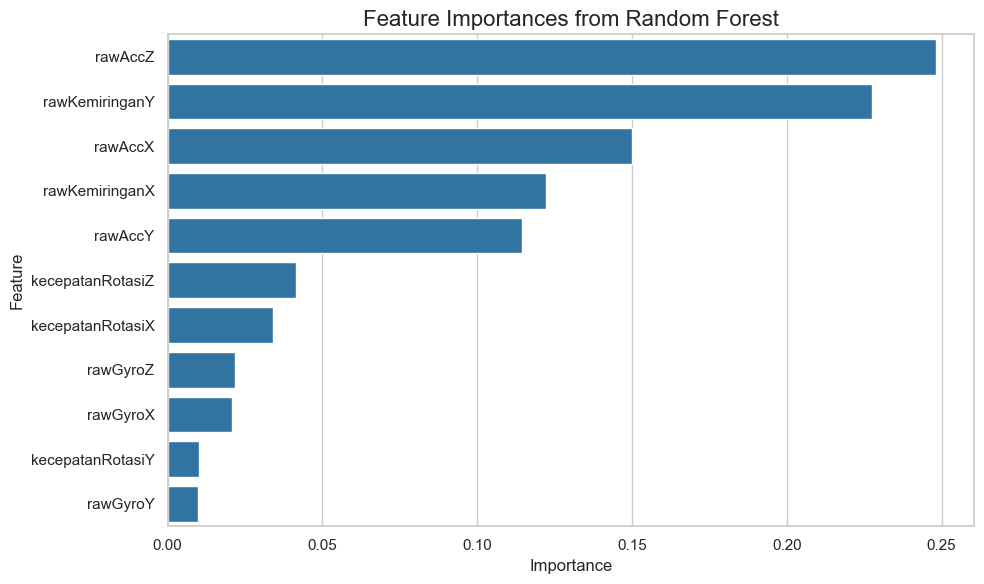

In [78]:
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': final_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importances, x='Importance', y='Feature')
plt.title('Feature Importances from Random Forest', fontsize=16)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 7 - Save Model

### 7.1 Safe Random Forest Model

In [82]:

classmap = {i: label for i, label in enumerate(sorted(y.unique()))}
label_to_id = {label: i for i, label in classmap.items()}

with open("model_rf.h", "w") as f:
    f.write(port(final_rf, classmap=classmap))

print("Saved to model_rf.h")
print(classmap)

Saved to model_rf.h
{0: 0, 1: 1, 2: 2, 3: 3}


# NOTE



Foot Note

~

By NoHaitch  
Github: @NoHaitch   
Mail: franciscotrianto@gmail.com  